<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
-클러스터(cluster) : 독립변수의특성이유사한데이터의그룹
-클러스터링(clustering) : 주어진데이터를여러개의클러스터로구분하는것
1) 중심기반클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반클러스터링(DBSCAN의변형으로OPTICS) : https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
# sklearn의 로직들이 멀티 쓰레드로 실행

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘
- 클러스터의 중심을 찾아가는 알고리즘
- 세부알고리즘 : 교안 6p

In [3]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

In [13]:
# 분류를 위한 가상의 데이터 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20, # 데이터 갯수(기본값 100)
                           n_features=2, # 독립변수갯수(기본값 20)
                           n_informative=2, # 종속변수에 영향을 미치는 독립변수 갯수
                           n_redundant=0, # 종속변수에 영향을 미치지 않는 독립변수 갯수
                           n_classes=2, # 종속변수의 클래스 수
                           n_clusters_per_class=1, # 각 종속변수 그룹별 서브그룹이 없음
                           random_state=123)
import numpy as np
np.c_[X,y][:3]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

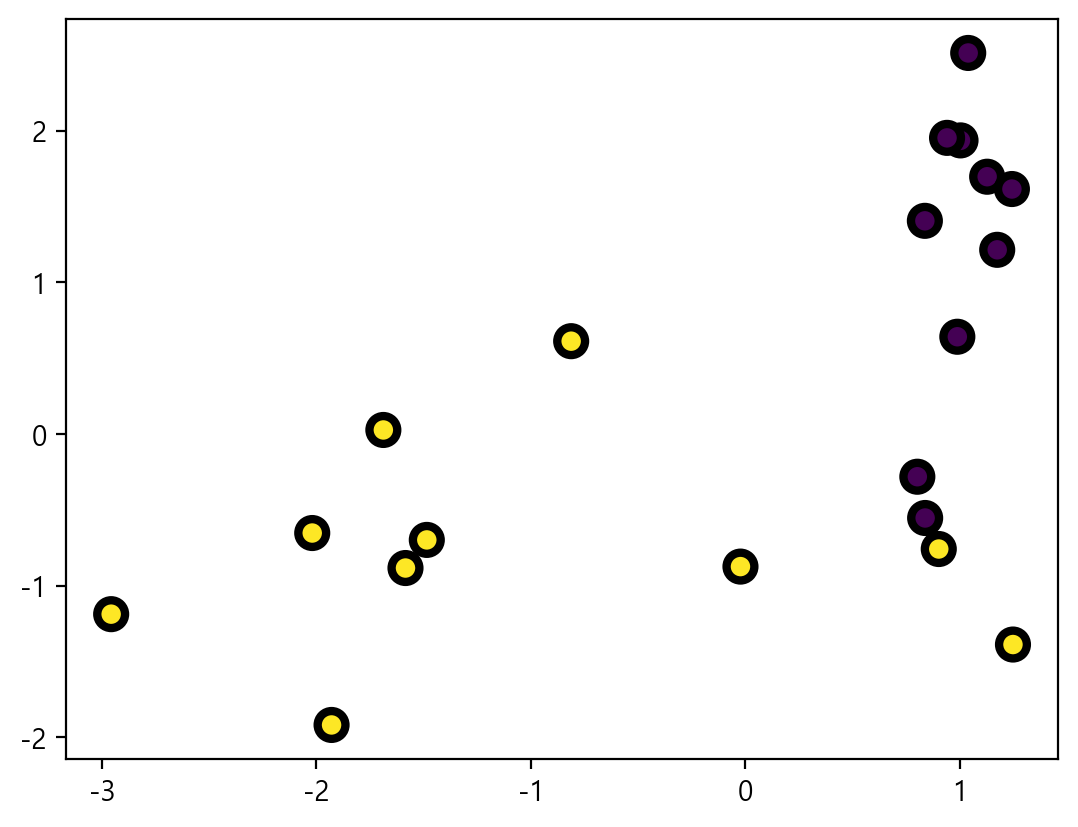

In [16]:
plt.scatter(x=X[:,0], y=X[:,1], c=y, s=100, edgecolors='k', lw=3)

In [18]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
               init="k-means++", # 초기중심점을 서로 멀리 초기화 / random(초기중심점랜덤)
               n_init=10, # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
               max_iter=300) # 각 실행에서 300번 반복(중심 옮기기)

In [19]:
model.fit(X)

KMeans(n_clusters=2, n_init=10)

In [28]:
c0, c1 = model.cluster_centers_ # 모델이 정한 두 중심점
print(c0, c1)

[1.01138251 0.83200493] [-1.56258716 -0.69768199]


In [45]:
print("modelLabel :", model.labels_)
pred = model.predict(X)
print("  예 측 값 :", pred)
print("  실 제 값 :", y)

modelLabel : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  예 측 값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  실 제 값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]


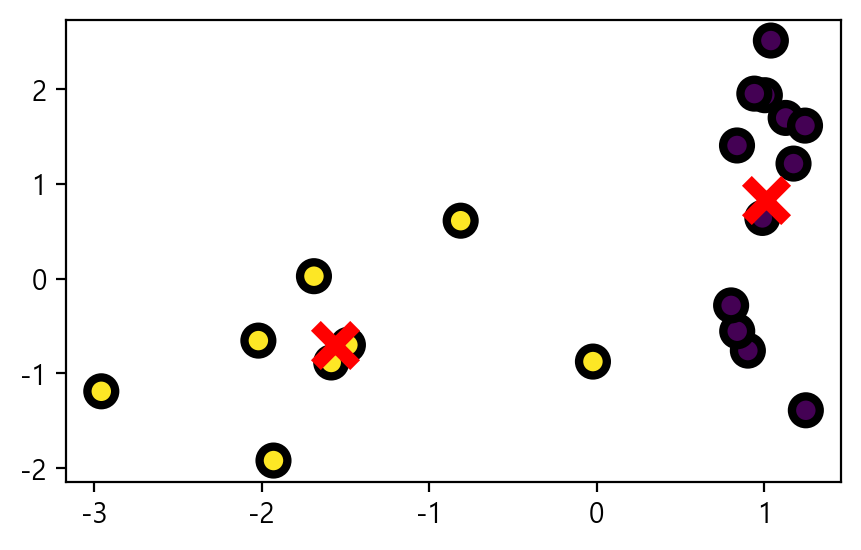

In [34]:
plt.figure(figsize=(5,3))
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3)
plt.scatter(x=c0[0], y=c0[1], s=200, marker='x', lw=5, c='r')
plt.scatter(x=c1[0], y=c1[1], s=200, marker='x', lw=5, c='r')
plt.show()

## cf. Normalizer 적용

In [61]:
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
np.c_[X, Xnor][:3]

array([[ 1.03859554,  2.51175389,  0.3821159 ,  0.92411441],
       [ 1.00271366,  1.93521549,  0.46005267,  0.88789162],
       [-1.6881048 ,  0.02599427, -0.99988146,  0.01539667]])

In [62]:
model = KMeans(n_clusters=2, # 군의 갯수
               init="k-means++", # 초기중심점을 서로 멀리 초기화 / random(초기중심점랜덤)
               n_init=10, # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
               max_iter=300) # 각 실행에서 300번 반복(중심 옮기기)
model.fit(Xnor)

KMeans(n_clusters=2, n_init=10)

In [63]:
model.labels_ # 모델이 그룹핑한 결과

array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0])

In [64]:
d0, d1 = model.cluster_centers_ # 모델이 정한 중심점
print(d0, d1)

[0.64128684 0.34902823] [-0.77398837 -0.33522479]


In [65]:
Xnor[model.labels_==0]

array([[ 0.3821159 ,  0.92411441],
       [ 0.46005267,  0.88789162],
       [ 0.76493676, -0.64410538],
       [ 0.51161542,  0.85921456],
       [ 0.83395074, -0.55183889],
       [ 0.55350265,  0.83284742],
       [ 0.94318094, -0.33227958],
       [ 0.43387458,  0.90097328],
       [ 0.60980605,  0.79255068],
       [ 0.66821427, -0.74396888],
       [ 0.83902767,  0.54408875],
       [ 0.69516439,  0.7188508 ]])

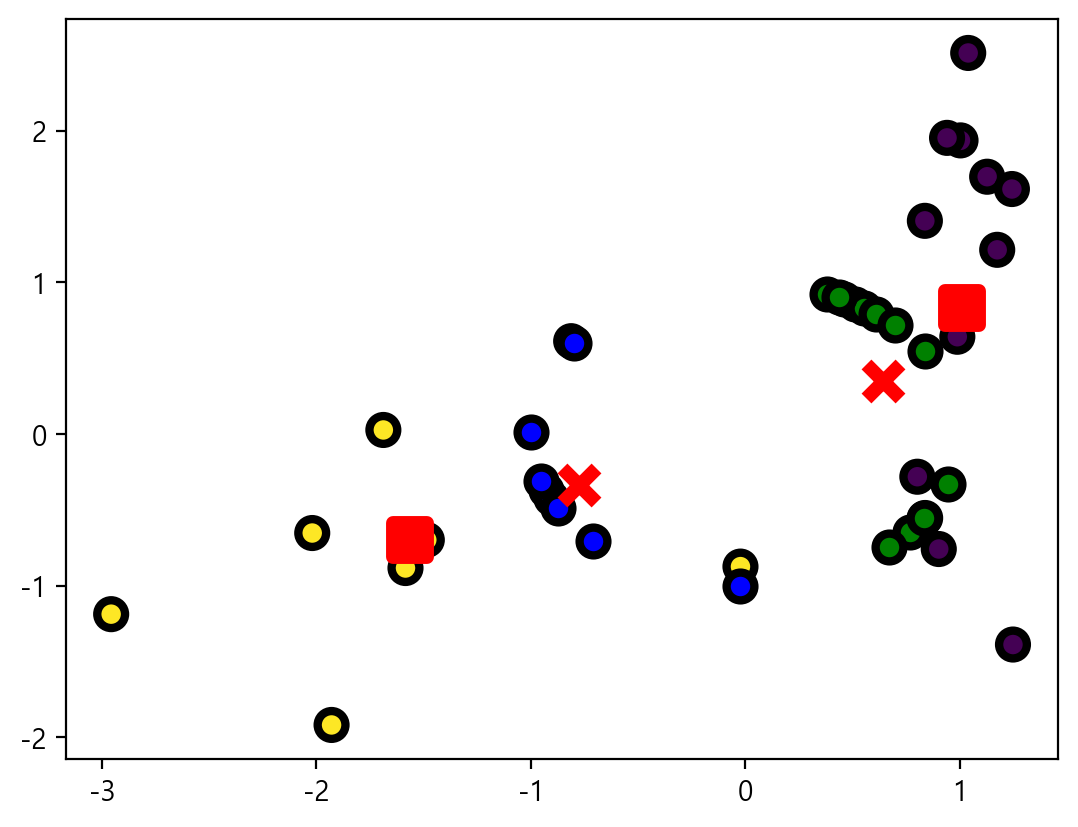

In [73]:
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3 )
plt.scatter(x=c0[0], y=c0[1], s=150, marker='s', lw=5, c='r')
plt.scatter(x=c1[0], y=c1[1], s=150, marker='s', lw=5, c='r')

plt.scatter(x=Xnor[model.labels_==0,0], 
            y=Xnor[model.labels_==0,1], 
            c='g', s=100, edgecolors='k', lw=3 )
plt.scatter(x=Xnor[model.labels_==1,0], 
            y=Xnor[model.labels_==1,1], 
            c='b', s=100, edgecolors='k', lw=3 )
plt.scatter(x=d0[0], y=d0[1], s=150, marker='x', lw=5, c='r')
plt.scatter(x=d1[0], y=d1[1], s=150, marker='x', lw=5, c='r')

plt.show()